In [15]:
import fastf1
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
import os
import logging

logging.getLogger('fastf1').setLevel(logging.ERROR)
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

all_results = []

for year in range(2018, 2026):
    schedule = fastf1.get_event_schedule(year, include_testing=False)
    for _, event in schedule.iterrows():
        try:
            session = fastf1.get_session(year, event['RoundNumber'], 'R')
            session.load(telemetry=False, weather=False, messages=False)
            results = session.results[['Abbreviation', 'GridPosition', 'Position', 'Points', 'TeamName']].copy()
            results['Year'] = year
            results['Round'] = event['RoundNumber']
            all_results.append(results)
        except:
            pass


Request for URL https://api.jolpi.ca/ergast/f1/2020/4/laps/1.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\matev\AppData\Local\Programs\Python\Python314\Lib\site-packages\requests_cache\session.py", line 316, in _resend
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\matev\AppData\Local\Programs\Python\Python314\Lib\site-packages\requests\models.py", line 1026, in raise_for_status
    raise HTTPError(http_error_msg, response=self)
requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://api.jolpi.ca/ergast/f1/2020/4/laps/1.json
Request for URL https://api.jolpi.ca/ergast/f1/2020/5/results.json failed; using cached response
Traceback (most recent call last):
  File "c:\Users\matev\AppData\Local\Programs\Python\Python314\Lib\site-packages\requests_cache\session.py", line 316, in _resend
    response.raise_for_status()
    ~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "c:\Users\matev\AppData\Local\Pr

In [23]:
df = pd.concat(all_results, ignore_index=True)
df['Position'] = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')
df = df.sort_values(['Year', 'Round']).reset_index(drop=True)

print(f"Skupaj vrstic: {len(df)}")
print(df.head())

Skupaj vrstic: 3458
  Abbreviation  GridPosition  Position  Points         TeamName  Year  Round
0          VET           3.0       1.0    25.0          Ferrari  2018      1
1          HAM           1.0       2.0    18.0         Mercedes  2018      1
2          RAI           2.0       3.0    15.0          Ferrari  2018      1
3          RIC           8.0       4.0    12.0  Red Bull Racing  2018      1
4          ALO          10.0       5.0    10.0          McLaren  2018      1


In [24]:
df['AvgPos_last5'] = df.groupby('Abbreviation')['Position'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['AvgGrid_last5'] = df.groupby('Abbreviation')['GridPosition'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df['CumPoints'] = df.groupby(['Year', 'Abbreviation'])['Points'].transform(
    lambda x: x.shift(1).cumsum().fillna(0)
)

df_model = df.dropna(subset=['GridPosition', 'AvgPos_last5', 'AvgGrid_last5'])

features = ['GridPosition', 'AvgPos_last5', 'AvgGrid_last5', 'CumPoints']

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df_model[features], df_model['Position'])

print(df_model[features].head())

    GridPosition  AvgPos_last5  AvgGrid_last5  CumPoints
20           1.0           1.0            3.0       25.0
21           3.0           8.0           15.0        4.0
22           9.0           2.0            1.0       18.0
23           5.0          18.0           20.0        0.0
24           6.0          17.0            5.0        0.0


In [25]:
all_2026 = []

schedule_2026 = fastf1.get_event_schedule(2026, include_testing=False)
for _, event in schedule_2026[schedule_2026['RoundNumber'] <= 5].iterrows():
    try:
        session = fastf1.get_session(2026, event['RoundNumber'], 'R')
        session.load(telemetry=False, weather=False, messages=False)
        results = session.results[['Abbreviation', 'GridPosition', 'Position', 'Points']].copy()
        results['Year'] = 2026
        results['Round'] = event['RoundNumber']
        all_2026.append(results)
    except:
        pass

df_2026 = pd.concat(all_2026, ignore_index=True)
df_2026['Position'] = pd.to_numeric(df_2026['Position'], errors='coerce')
df_2026['GridPosition'] = pd.to_numeric(df_2026['GridPosition'], errors='coerce')
df_2026 = df_2026.sort_values(['Year', 'Round']).reset_index(drop=True)

print(f"2026 vrstic: {len(df_2026)}")

2026 vrstic: 110


In [26]:
df_2026['AvgPos_last5'] = df_2026.groupby('Abbreviation')['Position'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
df_2026['AvgGrid_last5'] = df_2026.groupby('Abbreviation')['GridPosition'].transform(
    lambda x: x.rolling(5, min_periods=1).mean()
)
df_2026['CumPoints'] = df_2026.groupby('Abbreviation')['Points'].transform(
    lambda x: x.cumsum()
)

current_state = df_2026.groupby('Abbreviation').last().reset_index()
current_state = current_state[['Abbreviation', 'GridPosition', 'AvgPos_last5', 'AvgGrid_last5', 'CumPoints']]

print(current_state.sort_values('CumPoints', ascending=False).head(5))

   Abbreviation  GridPosition  AvgPos_last5  AvgGrid_last5  CumPoints
2           ANT           2.0           1.2            1.4      118.0
18          RUS           1.0           6.0            2.2       67.0
9           HAM           5.0           4.2            5.4       61.0
12          LEC           8.0           4.4            4.6       58.0
14          NOR           3.0          10.0            4.8       38.0


In [27]:
points_system = {1:25, 2:18, 3:15, 4:12, 5:10, 6:8, 7:6, 8:4, 9:2, 10:1}

current_state = current_state.copy()
all_predictions = []

for round_num in range(6, 23):
    current_state['GridPosition'] = current_state['AvgGrid_last5'].apply(
    lambda x: max(1, min(20, int(np.random.normal(x, 2))))
    )
    
    current_state['PredictedPosition'] = model.predict(current_state[features])
    
    current_state = current_state.sort_values('PredictedPosition').reset_index(drop=True)
    current_state['FinalPosition'] = range(1, len(current_state) + 1)
    
    current_state['RoundPoints'] = current_state['FinalPosition'].map(points_system).fillna(0)
    
    round_pred = current_state[['Abbreviation', 'FinalPosition', 'RoundPoints']].copy()
    round_pred['Round'] = round_num
    all_predictions.append(round_pred)
    
    current_state['AvgPos_last5'] = (current_state['AvgPos_last5'] * 4 + current_state['FinalPosition']) / 5
    current_state['AvgGrid_last5'] = (current_state['AvgGrid_last5'] * 4 + current_state['GridPosition']) / 5

pred_df = pd.concat(all_predictions, ignore_index=True)

schedule_2026 = fastf1.get_event_schedule(2026, include_testing=False)
print("Napovedi po dirkah:\n")
for round_num, race in pred_df.groupby('Round'):
    top3 = race.sort_values('FinalPosition').head(3)['Abbreviation'].tolist()
    event_name = schedule_2026[schedule_2026['RoundNumber'] == round_num]['EventName'].iloc[0]
    print(f"Dirka {round_num} - {event_name}")
    print(f"  1. {top3[0]}  2. {top3[1]}  3. {top3[2]}\n")

points_first5 = df_2026.groupby('Abbreviation')['Points'].sum().reset_index()
points_predicted = pred_df.groupby('Abbreviation')['RoundPoints'].sum().reset_index()
total = points_first5.merge(points_predicted, on='Abbreviation')
total['TotalPoints'] = total['Points'] + total['RoundPoints']
total = total.sort_values('TotalPoints', ascending=False)

print("\nNapoved prvaka 2026:")
print(total[['Abbreviation', 'TotalPoints']].head(5))

Napovedi po dirkah:

Dirka 6 - Monaco Grand Prix
  1. LEC  2. NOR  3. RUS

Dirka 7 - Barcelona Grand Prix
  1. RUS  2. LEC  3. ANT

Dirka 8 - Austrian Grand Prix
  1. RUS  2. LEC  3. PIA

Dirka 9 - British Grand Prix
  1. RUS  2. LEC  3. NOR

Dirka 10 - Belgian Grand Prix
  1. RUS  2. HAM  3. LEC

Dirka 11 - Hungarian Grand Prix
  1. RUS  2. ANT  3. LEC

Dirka 12 - Dutch Grand Prix
  1. LEC  2. ANT  3. RUS

Dirka 13 - Italian Grand Prix
  1. HAM  2. LEC  3. PIA

Dirka 14 - Spanish Grand Prix
  1. LEC  2. NOR  3. ANT

Dirka 15 - Azerbaijan Grand Prix
  1. LEC  2. RUS  3. NOR

Dirka 16 - Singapore Grand Prix
  1. RUS  2. LEC  3. ANT

Dirka 17 - United States Grand Prix
  1. RUS  2. HAM  3. NOR

Dirka 18 - Mexico City Grand Prix
  1. ANT  2. RUS  3. LEC

Dirka 19 - São Paulo Grand Prix
  1. ANT  2. NOR  3. RUS

Dirka 20 - Las Vegas Grand Prix
  1. LEC  2. RUS  3. ANT

Dirka 21 - Qatar Grand Prix
  1. RUS  2. HAM  3. LEC

Dirka 22 - Abu Dhabi Grand Prix
  1. ANT  2. RUS  3. LEC


Napoved p

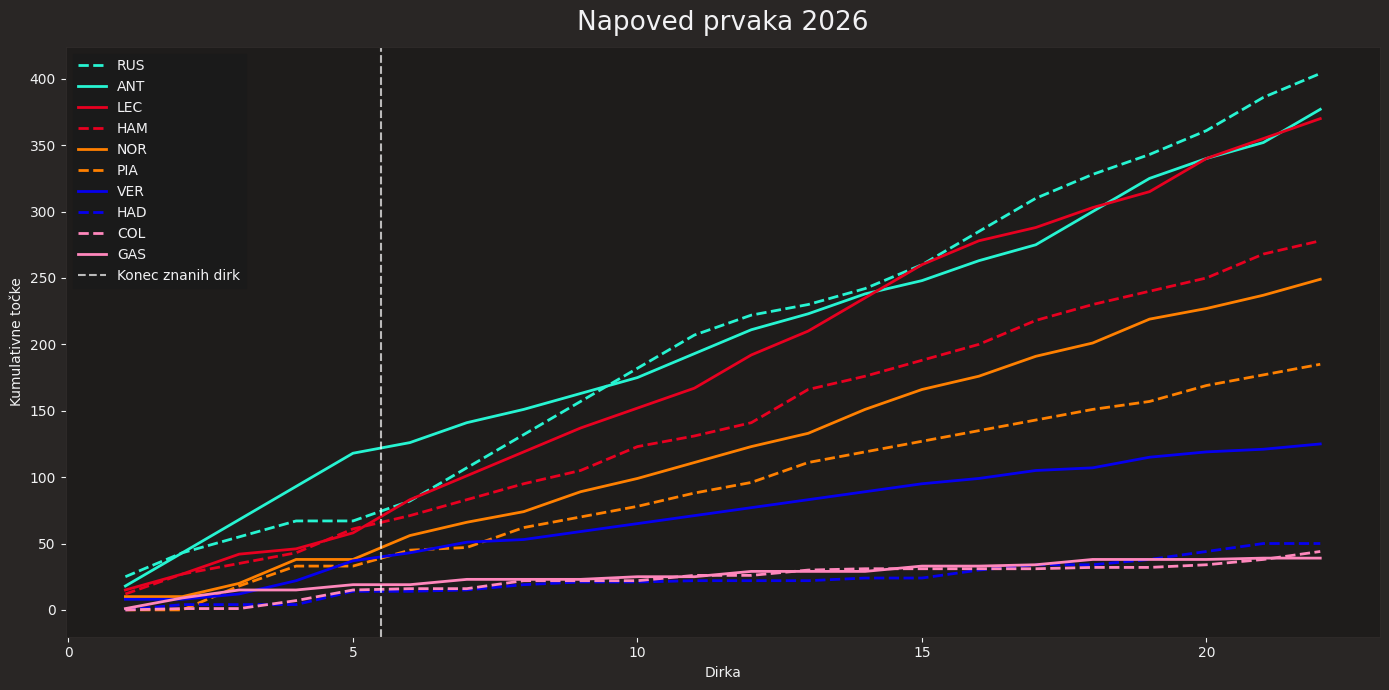

In [28]:
import matplotlib.pyplot as plt
import fastf1.plotting
fastf1.plotting.setup_mpl(color_scheme='fastf1')

top10_drivers = total.head(10)['Abbreviation'].tolist()

first10_by_round = df_2026.groupby(['Abbreviation', 'Round'])['Points'].sum().reset_index()
first10_by_round = first10_by_round[first10_by_round['Abbreviation'].isin(top10_drivers)]

pred_by_round = pred_df[pred_df['Abbreviation'].isin(top10_drivers)][['Abbreviation', 'Round', 'RoundPoints']].copy()
pred_by_round = pred_by_round.rename(columns={'RoundPoints': 'Points'})

all_rounds = pd.concat([first10_by_round, pred_by_round], ignore_index=True)
all_rounds = all_rounds.sort_values(['Abbreviation', 'Round'])
all_rounds['CumPoints'] = all_rounds.groupby('Abbreviation')['Points'].cumsum()

fig, ax = plt.subplots(figsize=(14, 7))

for driver in top10_drivers:
    driver_data = all_rounds[all_rounds['Abbreviation'] == driver]
    try:
        style = fastf1.plotting.get_driver_style(driver, ['color', 'linestyle'], session)
        ax.plot(driver_data['Round'], driver_data['CumPoints'],
                label=driver, color=style['color'], linestyle=style.get('linestyle', '-'), linewidth=2)
    except:
        ax.plot(driver_data['Round'], driver_data['CumPoints'], label=driver, linewidth=2)

ax.axvline(x=5.5, color='white', linestyle='--', alpha=0.7, label='Konec znanih dirk')
ax.set_xlabel('Dirka')
ax.set_ylabel('Kumulativne točke')
ax.set_title('Napoved prvaka 2026')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [29]:
importances = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importances)

         Feature  Importance
0   GridPosition    0.423018
2  AvgGrid_last5    0.200361
3      CumPoints    0.193616
1   AvgPos_last5    0.183005
